In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set_theme()

In [2]:
data = loadmat('cluster_dataset.mat')

In [3]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

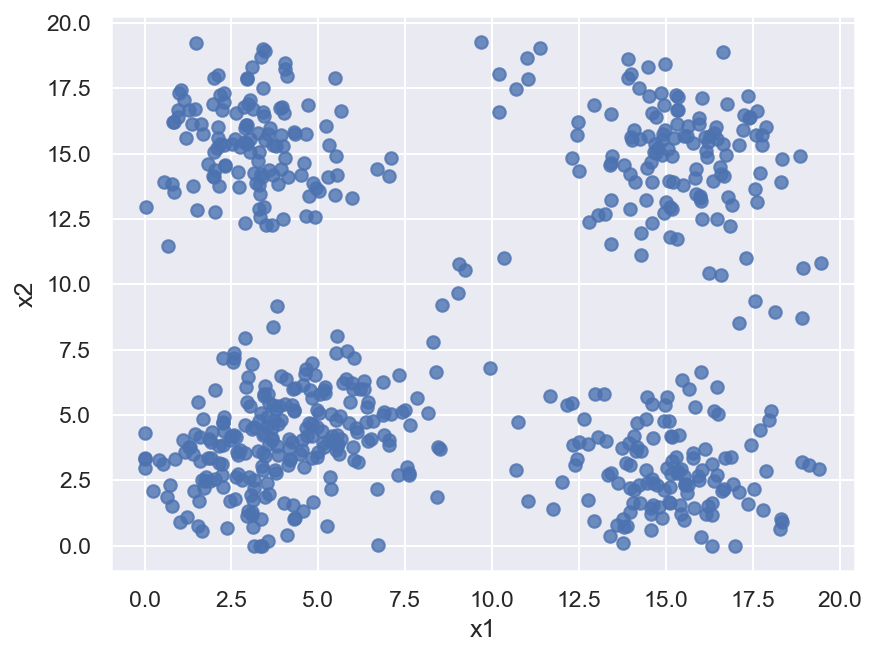

In [4]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [5]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 3

In [6]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（建议：元素为ndarray的list)
    可能使用的函数：random.randint
    注意：需保证随机取的样本不重复
    """
    indices=random.sample(range(X.shape[0]),k)
    centers=[X[i] for i in indices]
    return centers

In [7]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    """
    输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    输出：distance:欧氏距离(float/ndarray)
    """
    distance = np.sqrt(np.sum((v1-v2)**2))
    return distance

In [8]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心集（建议：元素为ndarray的list)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list)
    可能使用的函数：np.argmin
    注意：list和array在某些计算时的转换
    """
    assignment = {i: [] for i in range(len(centers))}
    
    for x in X:
        # 计算该样本到所有中心的距离
        distances = [distance(x, c) for c in centers]
        # 找到距离最小的簇标号
        closest_k = np.argmin(distances)
        # 将样本加入对应的簇
        assignment[closest_k].append(x)
    return assignment

In [9]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心（建议：元素为ndarray的list)
    输出：cost:代价函数值（float/ndarray）
    可能使用的函数：np.argmin
    注意：list和array在使用np函数计算时的转换
    """
    total_cost = 0.0
    num_points = 0
    
    for k in range(len(centers)):
        cluster_points = assignment[k]
        if len(cluster_points) > 0:
            for point in cluster_points:
                # 累加距离的平方
                total_cost += distance(point, centers[k]) ** 2
            num_points += len(cluster_points)
            
    # 计算平均代价
    cost = total_cost / num_points if num_points > 0 else 0
    return cost

In [10]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    """
    输入：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), centers：当前中心（建议：元素为ndarray的list)
    输出：new_centers:更新的中心集（建议：元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    可能使用的函数：np.mean
    注意：list和array在使用np函数计算时的转换
    """
    new_centers = []
    
    for k in range(len(centers)):
        cluster_points = assignment[k]
        # 如果簇内有样本，则取平均值作为新中心
        if len(cluster_points) > 0:
            new_center = np.mean(cluster_points, axis=0)
        else:
            new_center = centers[k] # 如果是空簇，中心保持不变
        new_centers.append(new_center)
        
    # 判断中心是否发生改变（停机条件）
    stop = 1
    for k in range(len(centers)):
        # 如果新老中心的距离大于一个极小值，说明还在移动，不停机
        if distance(new_centers[k], centers[k]) > 1e-5:
            stop = 0
            break
    return new_centers, stop

In [11]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [12]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot:是否可视化（True/False)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), cost:最终的代价函数值，用于k-cost曲线的绘制（float/ndarray）
    """
    # 初始化中心
    centers = init_centers(X, k)
    assignment = None
    cost = 0
    
    for epoch in range(max_epoch):
        # 分配簇
        assignment = cluster_assignment(X, centers)
        
        # 可视化当前轮次
        if plot:
            plot_clustering(assignment, centers, epoch)
            
        # 更新中心并检查是否停机
        new_centers, stop = center_update(assignment, centers)
        
        # 计算当前代价
        cost = cost_function(assignment, centers)
        
        # 如果中心不再改变，跳出循环
        if stop == 1:
            print(f"在第 {epoch} 轮达到收敛，提前停机！")
            break
            
        centers = new_centers
    return assignment, cost

In [13]:
max_epoch = 200 

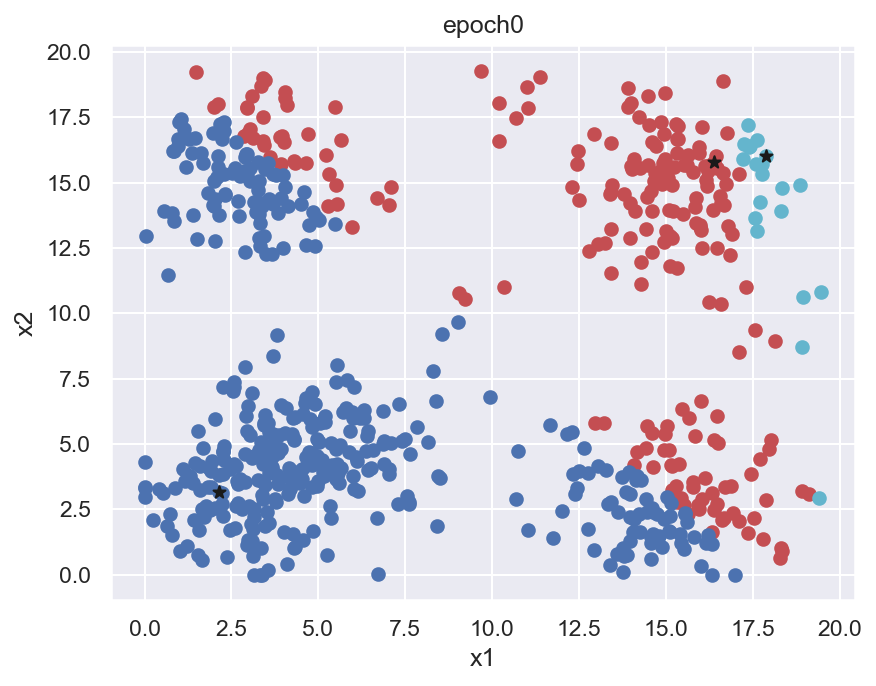

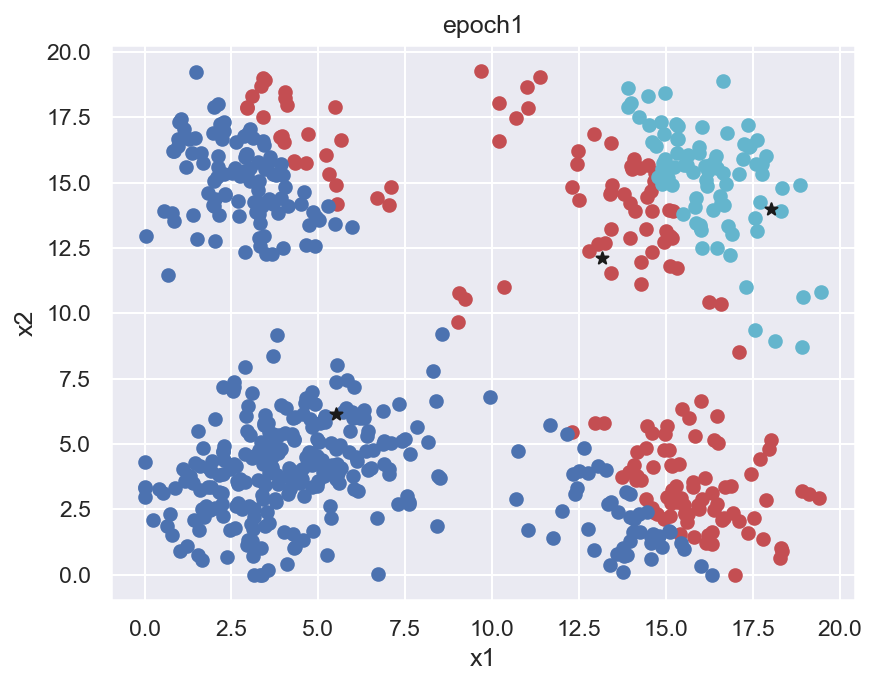

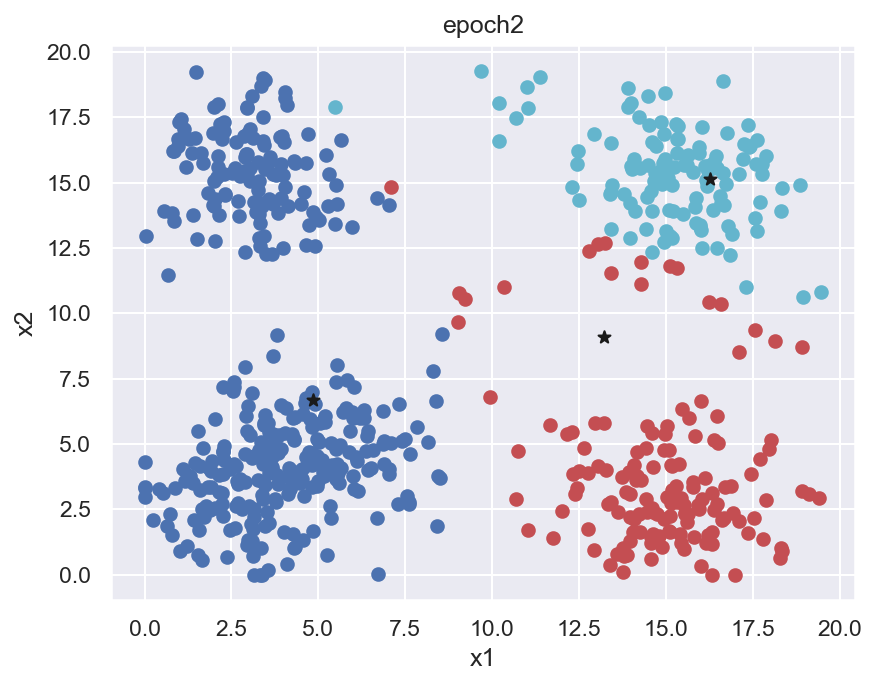

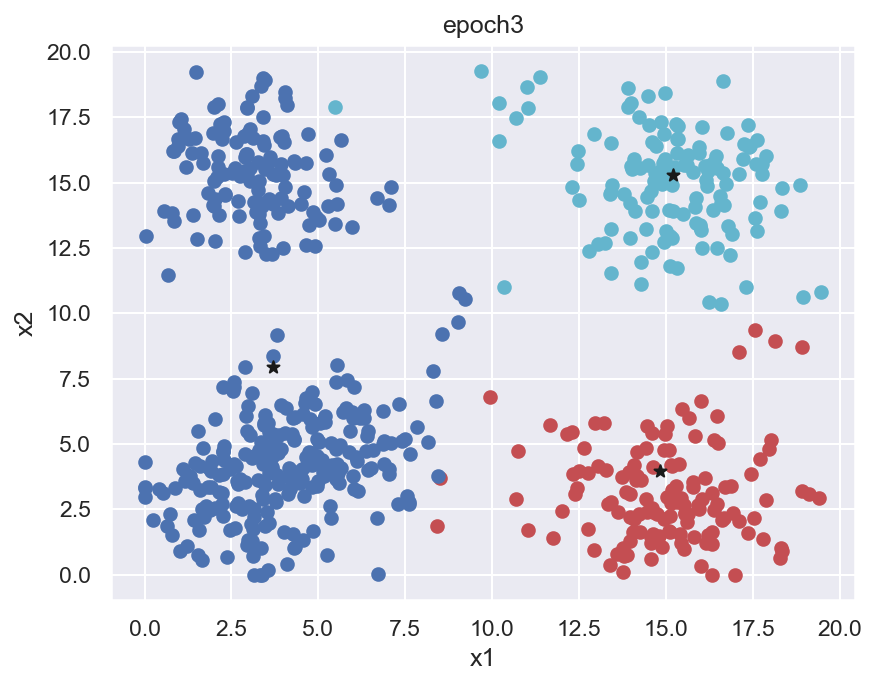

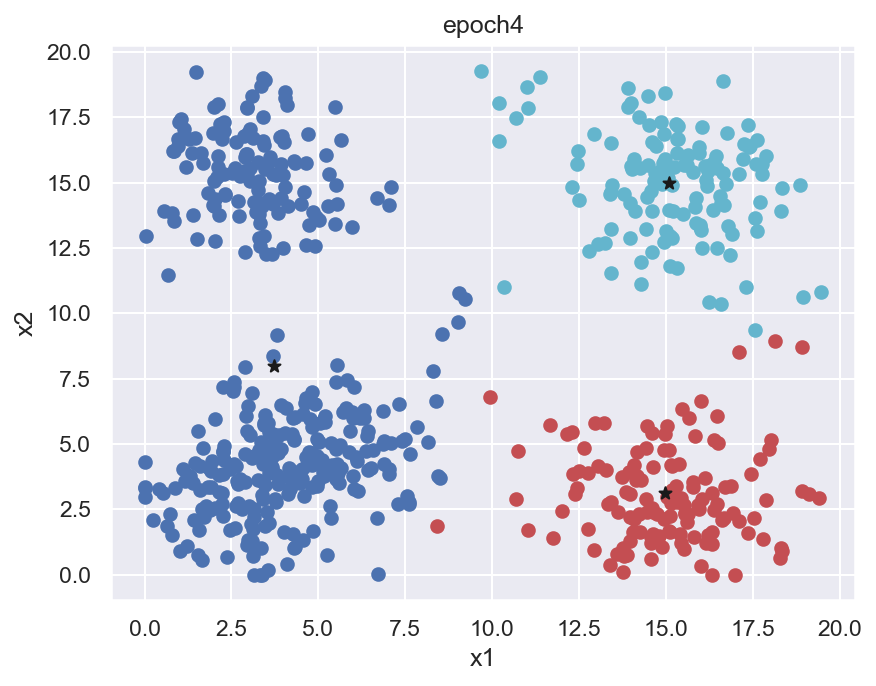

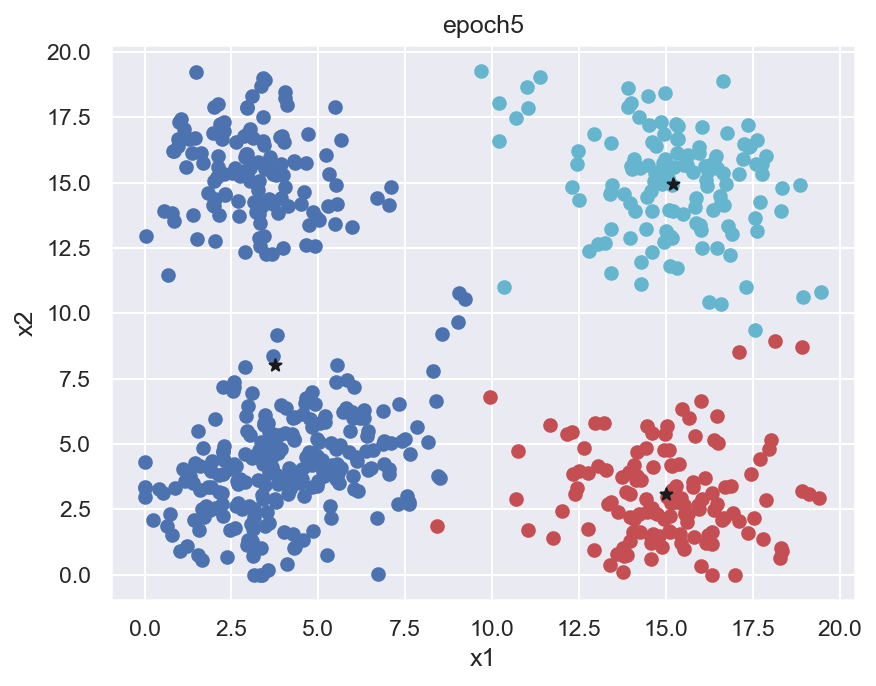

在第 5 轮达到收敛，提前停机！


In [14]:
assignment,cost= kmeans(X, k, max_epoch)

在第 1 轮达到收敛，提前停机！
在第 2 轮达到收敛，提前停机！
在第 4 轮达到收敛，提前停机！
在第 4 轮达到收敛，提前停机！
在第 7 轮达到收敛，提前停机！


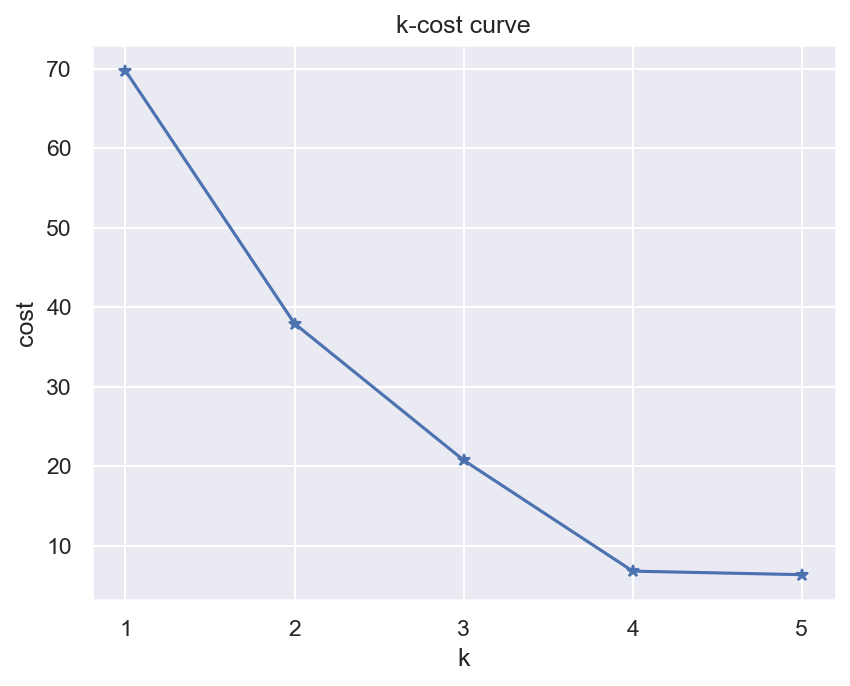

In [15]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch,False)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()